In [176]:
import os
import textwrap
import math
import json
import pandas as pd
import numpy as np
from collections import Counter
from datetime import datetime
from dateutil.relativedelta import relativedelta
from IPython.display import display
from IPython.display import Markdown

from langchain_openai import ChatOpenAI


def to_markdown(text):
  text = text.replace('•', '  *')
  return Markdown(textwrap.indent(text, '> ', predicate=lambda _: True))

llm = ChatOpenAI(
  openai_api_key = os.getenv('OPENAI_API_KEY'),
  model='gpt-4o-mini',
  temperature=1,
)

# 買進賣出需要的手續費
fee = {
  'tax_stock' : 0.003,          # 買進與賣出各0.003
  'tax_future' : 0.00002 * 2,   # 買進與賣出各0.00002
  'fee_stock' : 0.001425 * 2,   # 券商手續費公道價，買進與賣出各0.001425
  'fee_future' : 0.00002 * 2,   # 個家不大相同，以交易稅計算
  'sliding_price' : 0.00001,    # 滑價
}

env = {
    "stock_id" : "TSLA",
    "country" : "us",
    "start_date" : "20230701",
    "end_date" : "20240630",
    "path_out" : "out_stock/GA_factor_20230701_20240630/",
}

# 載入 factors

In [177]:
factors = {}
path_factors = f"{env['path_out']}{env['stock_id']}/factors.json"
print(path_factors)
with open(path_factors, "r") as f:
  factors = json.load(f)

# Access by index using list of keys
key_list = list(factors.keys())
value_list = list(factors.values())
print(key_list)
print(len(key_list))
print(len(value_list))

out_stock/GA_factor_20230701_20240630/TSLA/factors.json
['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20']
20
20


# 延伸factors

In [178]:
from api import factor_expanding

# 讀取舊資料
old_data = {}
path_expand = f"{env['path_out']}{env['stock_id']}/expand.json"
os.makedirs(os.path.dirname(path_expand), exist_ok=True)
if os.path.exists(path_expand):
    with open(path_expand, 'r') as f:
        old_data = json.load(f)

data = factor_expanding(llm, env, key_list, value_list, old_data)

# 儲存資料
with open(path_expand, 'w') as f:
    json.dump(data, f, ensure_ascii=False, indent=4)

running... factor_expanding
Processing for date 20240628
Processing for date 20240627
Processing for date 20240626
Processing for date 20240625
Processing for date 20240624
Processing for date 20240621
Processing for date 20240620
Processing for date 20240618
Processing for date 20240617
Processing for date 20240614
Processing for date 20240613
Processing for date 20240612
Processing for date 20240611
Processing for date 20240610
Processing for date 20240607
Processing for date 20240606
Processing for date 20240605
Processing for date 20240604
Processing for date 20240603
Processing for date 20240531
Processing for date 20240530
Processing for date 20240529
Processing for date 20240528
Processing for date 20240524
Processing for date 20240523
Processing for date 20240522
Processing for date 20240521
Processing for date 20240520
Processing for date 20240517
Processing for date 20240516
Processing for date 20240515
Processing for date 20240514
Processing for date 20240513
Processing for 

# GA 設定

In [179]:
import json
import random
from datetime import datetime
from datetime import timedelta

def split_expand(env, path_expand):
    # 解析日期
    start_day = datetime.strptime(env['start_date'], '%Y%m%d')
    end_day = datetime.strptime(env['end_date'], '%Y%m%d')

    # read train data
    with open(path_expand, 'r') as f:
        content = f.read().strip()
        data_points = json.loads(content)

    # split to training and testing
    total_days = (end_day - start_day).days + 1
    split_point = int(total_days * 3 / 4)
    training_end_day = start_day + timedelta(days=split_point - 1)
    testing_start_day = training_end_day + timedelta(days=1)
    train_datarange = {}
    for date_str, value in data_points["output_data"].items():
        date = datetime.strptime(date_str, '%Y%m%d')
        if start_day <= date <= training_end_day:
            train_datarange[date_str] = value
    test_datarange = {}
    for date_str, value in data_points["output_data"].items():
        date = datetime.strptime(date_str, '%Y%m%d')
        if testing_start_day <= date <= end_day:
            test_datarange[date_str] = value

    return train_datarange, test_datarange

In [180]:
train_datarange, test_datarange = split_expand(env, path_expand)
print(len(train_datarange))
print(train_datarange.keys())
print(len(test_datarange))
print(test_datarange.keys())


187
dict_keys(['20240328', '20240327', '20240326', '20240325', '20240322', '20240321', '20240320', '20240319', '20240318', '20240315', '20240314', '20240313', '20240312', '20240311', '20240308', '20240307', '20240306', '20240305', '20240304', '20240301', '20240229', '20240228', '20240227', '20240226', '20240223', '20240222', '20240221', '20240220', '20240216', '20240215', '20240214', '20240213', '20240212', '20240209', '20240208', '20240207', '20240206', '20240205', '20240202', '20240201', '20240131', '20240130', '20240129', '20240126', '20240125', '20240124', '20240123', '20240122', '20240119', '20240118', '20240117', '20240116', '20240112', '20240111', '20240110', '20240109', '20240108', '20240105', '20240104', '20240103', '20240102', '20231229', '20231228', '20231227', '20231226', '20231222', '20231221', '20231220', '20231219', '20231218', '20231215', '20231214', '20231213', '20231212', '20231211', '20231208', '20231207', '20231206', '20231205', '20231204', '20231201', '20231130', '

# GA Training and Testing

Accuracy

In [181]:
from api import genetic_algorithm
from api import eval

# setting --------------------------------
mode = 0     # 0: 準確率, 1: 期望值
out_folder = f"{env['path_out']}/{env['stock_id']}/ac"
# ----------------------------------------

state_file= out_folder + '/state.json'
file_gen= out_folder + '/generation_results.json'
file_result= out_folder + '/result.json'

print("Start, 第一次跑的話請確認state是空的")
best_individual = genetic_algorithm(factors, population_size=20, generations=50, state_file=state_file, results_file=file_gen, env=env, mode=mode, datarange=train_datarange)
print(f"Best individual: {best_individual}")

individual = best_individual
res_train = eval(individual, train_datarange, env)
res_test = eval(individual, test_datarange, env)
res = {
    "train": res_train,
    "test": res_test,
    "individual": individual,
}
print(res)
print(file_result)
with open(file_result, 'w') as f:
    json.dump(res, f, ensure_ascii=False, indent=4)

Start, 第一次跑的話請確認state是空的
Generation 1
Best fitness = 0.5297297297297298
Best individual: [1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1]

Generation 2
Best fitness = 0.5347593582887701
Best individual: [1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1]

Generation 3
Best fitness = 0.5303867403314917
Best individual: [0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1]

Generation 4
Best fitness = 0.532608695652174
Best individual: [0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1]

Generation 5
Best fitness = 0.532608695652174
Best individual: [0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1]

Generation 6
Best fitness = 0.5355191256830601
Best individual: [0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1]

Generation 7
Best fitness = 0.5380434782608695
Best individual: [0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0]

Generation 8
Best fitness = 0.5380434782608695
Best individual: [0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 

In [182]:
df = pd.DataFrame([res['train'], res['test']], index=['train', 'test'])
df

,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,30,24,69,60,183,187,0.540984,0.555556,0.333333,0.002019,0.001864,"[[20230703, 0.012043835220080235], [20230705, ..."
test,1,3,30,29,63,63,0.492063,0.250000,0.033333,-0.002322,-0.009307,"[[20240401, -0.005392518589998233], [20240402,..."


Expected Value

In [183]:
from api import genetic_algorithm
from api import eval

# setting --------------------------------
mode = 0     # 0: 準確率, 1: 期望值
out_folder = f"{env['path_out']}/{env['stock_id']}/ev"
# ----------------------------------------

state_file= out_folder + '/state.json'
file_gen= out_folder + '/generation_results.json'
file_result= out_folder + '/result.json'

print("Start, 第一次跑的話請確認state是空的")
best_individual = genetic_algorithm(factors, population_size=20, generations=50, state_file=state_file, results_file=file_gen, env=env, mode=mode, datarange=train_datarange)
print(f"Best individual: {best_individual}")

individual = best_individual
res_train = eval(individual, train_datarange, env)
res_test = eval(individual, test_datarange, env)
res = {
    "train": res_train,
    "test": res_test,
    "individual": individual,
}
print(res)
print(file_result)
with open(file_result, 'w') as f:
    json.dump(res, f, ensure_ascii=False, indent=4)

Start, 第一次跑的話請確認state是空的
Generation 1
Best fitness = 0.5355191256830601
Best individual: [0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0]

Generation 2
Best fitness = 0.5359116022099447
Best individual: [0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1]

Generation 3
Best fitness = 0.5401069518716578
Best individual: [1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0]

Generation 4
Best fitness = 0.5401069518716578
Best individual: [1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0]

Generation 5
Best fitness = 0.5401069518716578
Best individual: [1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0]

Generation 6
Best fitness = 0.5409836065573771
Best individual: [1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1]

Generation 7
Best fitness = 0.5409836065573771
Best individual: [1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1]

Generation 8
Best fitness = 0.5409836065573771
Best individual: [1, 0, 0, 0, 0, 1, 1, 0, 0, 1

In [184]:
df = pd.DataFrame([res['train'], res['test']], index=['train', 'test'])
df

,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,29,22,71,61,183,187,0.546448,0.568627,0.322222,0.002067,0.002242,"[[20230703, 0.012043835220080235], [20230705, ..."
test,1,3,30,29,63,63,0.492063,0.250000,0.033333,-0.002322,-0.009307,"[[20240401, -0.005392518589998233], [20240402,..."


# show old data

In [185]:
import os
import json
import pandas as pd
from api import eval

folders = os.listdir(env['path_out'])
results = []
index = []

for folder in folders:
    if folder == "factors_eng.json" or folder == "factors.json" or folder == "old_expand" or folder == ".DS_Store":
        continue
    folders_result = os.listdir(f"{env['path_out']}{folder}")
    # print(f"{folder}:")
    for file in folders_result:
        if file == "factors.json" or file == "factors1.json" or file == "factors2.json" or file == "expand.json" or file == "expand1.json" or file == "expand2.json":
            continue
        path = f"{env['path_out']}{folder}/{file}/result.json"
        with open(path, 'r') as f:
            json_data = json.load(f)
        # print(json_data)
        results.append(json_data['test'])
        index.append(f"{folder}_{file}")
        

print(f"共有 {len(results), len(index)} 筆資料")
print(results)

df = pd.DataFrame(results, index=index)
selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']  # 替換為您需要的欄位名稱
df['accuracy'] = df['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
df['precision'] = df['precision'].apply(lambda x: f"{x * 100:.2f}%")
df_selected = df.loc[:, selected_columns]
df_sorted = df_selected.sort_index()
df_sorted

共有 (16, 16) 筆資料
[{'tp': 25, 'fp': 24, 'tn': 6, 'fn': 8, 'avail_count': 63, 'ttl_count': 63, 'accuracy': 0.49206349206349204, 'precision': 0.5102040816326531, 'recall': 0.7575757575757576, 'ev': -0.0006105907295338086, 'precision_ev': -0.0005271681513385265, 'rtn_list': [['20240401', 0.0009956302892859495], ['20240402', 0.00904674149773834], ['20240403', -0.01395219566425787], ['20240404', 0.021739130434782608], ['20240405', -0.014749424278977945], ['20240408', -0.009149277688603574], ['20240409', -0.008384960478530344], ['20240410', 0.017426750198342146], ['20240411', 0.012370140302024216], ['20240412', -0.008470061794161536], ['20240415', -0.020301453914899327], ['20240416', 0.00027282152016141727], ['20240417', -0.016439693993814775], ['20240418', 0.012398743593982476], ['20240419', -0.022994293387042706], ['20240422', 0.0016389736633886745], ['20240423', 0.008198562443845347], ['20240424', -0.01861731688340555], ['20240425', -0.0235148514851484], ['20240426', 0.010264630613909375], 

,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
2330_ac,65.00%,57.69%,0.005523,0.004436,40,15,11,11,3
2330_ev,65.96%,60.61%,0.005146,0.004130,47,20,13,11,3
2454_ac,50.00%,48.72%,0.004024,0.002641,54,19,20,8,7
2454_ev,47.17%,48.00%,0.003754,0.004280,53,12,13,13,15
AAPL_ac,48.39%,45.65%,-0.000976,-0.000558,62,21,25,9,7
AAPL_ev,54.55%,51.52%,-0.000383,0.000694,44,17,16,7,4
AMZN_ac,49.21%,51.02%,-0.000611,-0.000527,63,25,24,6,8
AMZN_ev,49.21%,50.98%,-0.000796,-0.000621,63,26,25,5,7
GOOGL_ac,33.87%,52.63%,-0.002979,-0.000057,62,10,9,11,32
GOOGL_ev,32.26%,50.00%,-0.002914,-0.000129,62,10,10,10,32


[175.22, 173.220524430956, 168.61595494846017, 167.58484662161592, 171.72788340230173, 168.03655533105822, 164.178449237343, 165.3928991623534, 163.42792991701683, 164.65122125734962, 173.12364077223677, 172.7171798376807, 175.11663824826508, 176.64492890934085, 178.92161725938402, 177.0249666495627, 175.35759969932963, 176.1221777869403, 163.6908061540171, 164.23369541339673, 169.14100729736566, 165.79400907830345, 167.62503082691546, 170.2375832596876, 171.08830374714677, 170.1946978080975, 174.47755780228152, 171.29488540924498, 174.27035224910614, 178.8826505056846, 176.89389633241555, 173.79792874920906, 179.5074660416372, 178.7444819814947, 174.71745274180788, 177.28566941029246, 166.08346968514778, 168.5722238931724, 176.0457779337608, 171.61027216089946, 171.26977558915164, 169.3033047746485, 169.09946767244185, 169.49734877284757, 171.2481775032245, 171.25307660714392, 171.59489911534183, 168.3123850085535, 167.0223054096121, 169.1757794143822, 172.3468525565791, 166.132616463

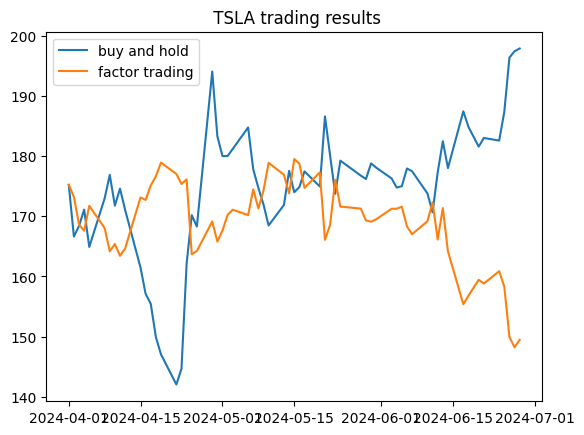

In [186]:
path_price_his = f"{os.path.dirname(os.path.abspath(os.getcwd()))}/history_data/{env['country']}/stock_price/{env['stock_id']}.csv"
df_price_his = pd.read_csv(path_price_his, encoding='utf-8')
df_price_his['Date'] = pd.to_datetime(df_price_his['Date'], format='%Y%m%d')
list_price_rtn = []
list_balance = []
balance = df_price_his[df_price_his['Date'].dt.strftime('%Y%m%d') == res_test['rtn_list'][0][0]]['Open'].values[0]
list_date = []

for date, rtn in res_test['rtn_list']:
    balance = balance * (1 + float(rtn))
    list_date.append(date)
    list_balance.append(balance)
    list_price_rtn.append(df_price_his[df_price_his['Date'].dt.strftime('%Y%m%d') == date]['Close'].values[0])

print(list_balance)
print(list_price_rtn)
print(list_date)
print(len(list_balance))
print(len(list_price_rtn))
print(len(list_date))

df = pd.DataFrame(list_balance, index=list_date, columns=['balance'])
dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]


import matplotlib.pyplot as plt
from datetime import datetime

plt.title(f" {env['stock_id']} trading results")
plt.plot(dplot, list_price_rtn, label = "buy and hold") # blue
plt.plot(dplot, list_balance, label = "factor trading") # orange
plt.legend()


In [187]:
# import os
# import json
# import pandas as pd
# from api import eval

# folders = os.listdir(env['path_out'])
# results = []
# index = []
# print(env['start_date'], env['end_date'])

# for folder in folders:
#     if folder == "factors_eng.json" or folder == "factors.json" or folder == "old_expand":
#         continue
#     folders_result = os.listdir(f"{env['path_out']}{folder}")
#     print(f"{folder}:")
#     for file in folders_result:
#         if file == "factors.json" or file == "expand.json" or file == "expand1.json" or file == "expand2.json":
#             continue
#         path = f"{env['path_out']}{folder}/{file}/generation_results.json"
#         with open(path, 'r') as f:
#             content = f.read().strip()
#         # print(file)
#         best_individual = []
#         for text in content.split('\n'):
#             data = json.loads(text)
#             best_individual = data['best_individual']

#         try:
#             individual = best_individual
#             print(f"{env['path_out']}{folder}/expand.json")
#             train_datarange, test_datarange = split_expand(env, f"{env['path_out']}{folder}/expand.json")
#             res_train = eval(individual, train_datarange)
#             res_test = eval(individual, test_datarange)
#             res = {
#                 "train": res_train,
#                 "test": res_test,
#                 "individual": individual,
#             }

#             file_result = f"{env['path_out']}{folder}/{file}/result.json"
#             print(file_result)
#             with open(file_result, 'w') as f:
#                 json.dump(res, f, ensure_ascii=False, indent=4)
#         except:
#             print("\tError")
#             pass


